# 📝 Week 4: Klasifikasi Sentimen dengan TF-IDF

Notebook ini mengadaptasi Colab Week-4 (Sentiment Analysis IMDB) untuk dataset **Google Apps Review Indonesia** (`cleandata.csv`).

## Tujuan Pembelajaran:
1. Memahami konsep **TF-IDF Vectorization** sebagai representasi fitur teks
2. Menerapkan pipeline klasifikasi sentimen biner (positif/negatif)
3. Membandingkan performa 3 model: **Linear SVM**, **Logistic Regression**, **Multinomial NB**
4. Menganalisis hasil evaluasi dengan confusion matrix, precision, recall, dan F1 score

## 📦 Import Libraries

Import semua library yang akan digunakan dalam notebook ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from timeit import default_timer as timer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


---

## 1️⃣ Load Dataset

Dataset `cleandata.csv` berisi review aplikasi Indonesia yang sudah melalui preprocessing di Week 3.

In [2]:
df = pd.read_csv("../Week 3/cleandata.csv")
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
print(f"\nSample data:")
df.head(10)

Shape: (39164, 4)
Kolom: ['score', 'content', 'text_final', 'reviewCreatedVersion']

Sample data:


,score,content,text_final,reviewCreatedVersion
0,5,ini adalah pertama kali saya menggunakan kartu...,kali kartu kredit cocok anak muda update alam ...,3.831.0
1,5,"pengajuan berhasil, pelayanan utk CS atas nama...",hasil layan cs nama sangat sopan jelas sangat ...,3.833.1
2,5,Pengajuan cepat dan aman..,cepat aman,3.833.1
3,5,cs Ridwan terbaik,cs baik,3.833.1
4,5,penjelasan yang baik oleh mba rima,jelas baik,3.833.1
5,5,trimakasih mba ulfa atas panduan nya sangat de...,trimakasih ulfa sangat trimakasih tuju,3.833.1
6,5,ok mantep gampang aktifnya dan costemernya mas...,mantep gampang aktif fariz ramah enak ajak ngo...,3.833.1
7,5,Alhamdulillah pelayanan mba azmi cukup memberi...,alhamdulillah layan info cepat limit,3.833.1
8,1,kartu kridit apa2an 😁😁😁 isi saldo dulu baru bi...,kartu kridit isi saldo dipake kecuali tipu,NaN
9,5,honest aktifasi dan palayanannya cepat dan CS ...,aktifasi cepat cs ramah,3.833.1


---

## 2️⃣ Exploratory Data Analysis (EDA)

Melihat distribusi score review dan panjang teks untuk memahami karakteristik dataset.

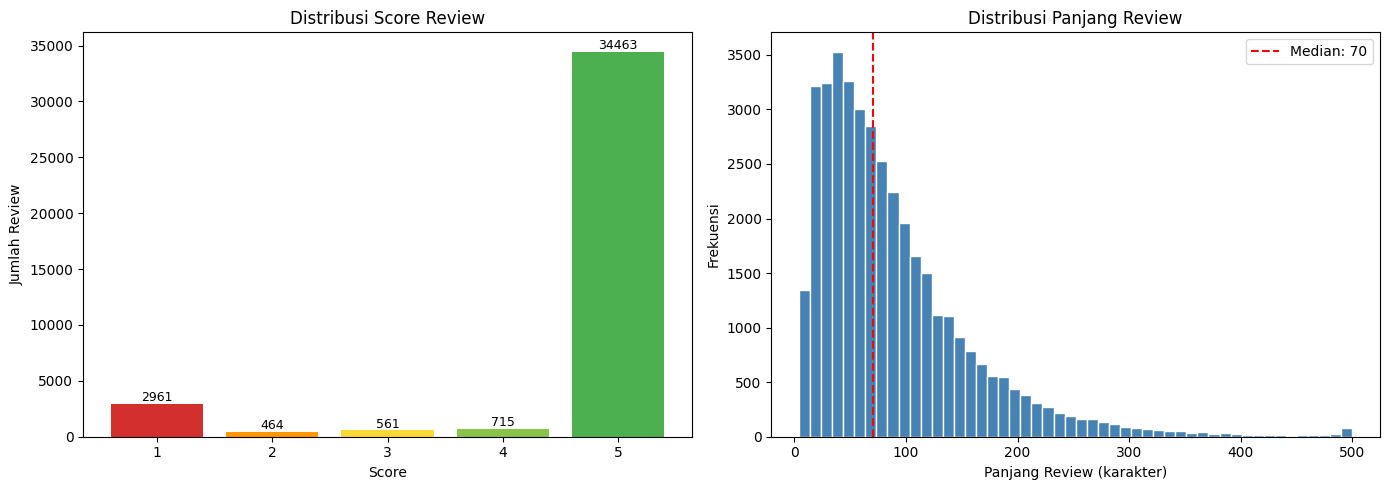


Statistik panjang review:
count    39164.000000
mean        88.742263
std         70.924866
min          4.000000
25%         39.000000
50%         70.000000
75%        117.000000
max        500.000000
Name: review_length, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart distribusi score
score_counts = df['score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
            color=['#d32f2f', '#ff9800', '#fdd835', '#8bc34a', '#4caf50'])
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Jumlah Review')
axes[0].set_title('Distribusi Score Review')
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, v in enumerate(score_counts.values):
    axes[0].text(score_counts.index[i], v + 200, str(v), ha='center', fontsize=9)

# Distribusi panjang review
df['review_length'] = df['content'].astype(str).apply(len)
axes[1].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Panjang Review (karakter)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Panjang Review')
axes[1].axvline(df['review_length'].median(), color='red', linestyle='--',
                label=f"Median: {df['review_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nStatistik panjang review:")
print(df['review_length'].describe())

---

## 3️⃣ Preprocessing & Labeling Sentimen Biner

Untuk klasifikasi sentimen biner:
- **Score ≤ 2** → `0` (Negatif)
- **Score ≥ 4** → `1` (Positif)
- **Score = 3** (Netral) → dihapus dari dataset

Kolom `text_final` digunakan karena sudah melalui preprocessing di Week 3.

In [4]:
# Hapus score netral (3) dan buat label sentimen biner
df_sentiment = df[df['score'] != 3].copy()
df_sentiment['label'] = df_sentiment['score'].apply(lambda x: 1 if x >= 4 else 0)

# Hapus baris dengan text_final kosong/NaN
df_sentiment = df_sentiment.dropna(subset=['text_final'])
df_sentiment = df_sentiment[df_sentiment['text_final'].str.strip() != '']

print(f"Dataset setelah filter: {df_sentiment.shape[0]} baris")
print(f"\nDistribusi label sentimen:")
print(df_sentiment['label'].value_counts().rename({0: 'Negatif (0)', 1: 'Positif (1)'}))
print(f"\nRasio Positif: {df_sentiment['label'].mean():.2%}")

Dataset setelah filter: 38603 baris

Distribusi label sentimen:
label
Positif (1)    35178
Negatif (0)     3425
Name: count, dtype: int64

Rasio Positif: 91.13%


---

## 4️⃣ Train/Test Split

Membagi dataset menjadi **80% training** dan **20% testing** dengan stratified split.

In [5]:
X = df_sentiment['text_final'].values
y = df_sentiment['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nDistribusi label di training set:")
print(f"  Positif: {sum(y_train == 1)}, Negatif: {sum(y_train == 0)}")
print(f"Distribusi label di test set:")
print(f"  Positif: {sum(y_test == 1)}, Negatif: {sum(y_test == 0)}")

Training set: 30882 samples
Test set: 7721 samples

Distribusi label di training set:
  Positif: 28142, Negatif: 2740
Distribusi label di test set:
  Positif: 7036, Negatif: 685


---

## 5️⃣ TF-IDF Vectorization

Mengubah teks menjadi representasi numerik menggunakan **TF-IDF** dengan maksimal 5000 fitur.

In [6]:
tfidf_vec = TfidfVectorizer(max_features=5000)

start = timer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)
print(f"TF-IDF vectorization time: {timer() - start:.2f}s")

print(f"\nTF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"\nSample feature names (first 20):")
print(tfidf_vec.get_feature_names_out()[:20])

TF-IDF vectorization time: 0.31s

TF-IDF matrix shape (train): (30882, 3086)
TF-IDF matrix shape (test): (7721, 3086)

Sample feature names (first 20):
['aa' 'aac' 'aamiin' 'abai' 'abal' 'abang' 'abis' 'aca' 'acc' 'accnya'
 'account' 'acha' 'achmad' 'activasi' 'acung' 'ad' 'ada' 'adain' 'adakan'
 'adam']


---

## 6️⃣ Klasifikasi Sentimen

Training dan evaluasi 3 classifier:

| Model | Karakteristik |
|-------|---------------|
| **Linear SVM** | Cepat dan efektif untuk text classification |
| **Logistic Regression** | Baseline yang solid, mudah diinterpretasi |
| **Multinomial NB** | Cocok untuk fitur TF-IDF non-negatif |

In [7]:
def evaluate_model(model, X_test, y_test):
    """Evaluasi model: return predictions dan semua metrik."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred, target_names=['Negatif', 'Positif'])
    cm = confusion_matrix(y_test, y_pred)
    return y_pred, acc, prec, rec, f1, report, cm

print("✅ Fungsi evaluate_model siap digunakan.")

✅ Fungsi evaluate_model siap digunakan.


### 6.1 Linear SVM

In [8]:
start = timer()
svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)
print(f"🔵 Linear SVM training time: {timer() - start:.2f}s")

start = timer()
y_pred_svm, acc_svm, prec_svm, rec_svm, f1_svm, report_svm, cm_svm = evaluate_model(svm_model, X_test_tfidf, y_test)
print(f"🔵 Linear SVM prediction time: {timer() - start:.2f}s")

print(f"\nAccuracy : {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")
print(f"\nClassification Report:\n{report_svm}")
print(f"Confusion Matrix:\n{cm_svm}")

🔵 Linear SVM training time: 0.06s
🔵 Linear SVM prediction time: 0.02s

Accuracy : 0.9650
Precision: 0.9646
Recall   : 0.9650
F1 Score : 0.9648

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.81      0.79      0.80       685
     Positif       0.98      0.98      0.98      7036

    accuracy                           0.97      7721
   macro avg       0.90      0.89      0.89      7721
weighted avg       0.96      0.97      0.96      7721

Confusion Matrix:
[[ 540  145]
 [ 125 6911]]


### 6.2 Logistic Regression

In [9]:
start = timer()
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
print(f"🟠 Logistic Regression training time: {timer() - start:.2f}s")

start = timer()
y_pred_lr, acc_lr, prec_lr, rec_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_model, X_test_tfidf, y_test)
print(f"🟠 Logistic Regression prediction time: {timer() - start:.2f}s")

print(f"\nAccuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"\nClassification Report:\n{report_lr}")
print(f"Confusion Matrix:\n{cm_lr}")

🟠 Logistic Regression training time: 0.09s
🟠 Logistic Regression prediction time: 0.02s

Accuracy : 0.9644
Precision: 0.9628
Recall   : 0.9644
F1 Score : 0.9631

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.85      0.73      0.78       685
     Positif       0.97      0.99      0.98      7036

    accuracy                           0.96      7721
   macro avg       0.91      0.86      0.88      7721
weighted avg       0.96      0.96      0.96      7721

Confusion Matrix:
[[ 498  187]
 [  88 6948]]


### 6.3 Multinomial Naive Bayes

In [10]:
start = timer()
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print(f"🟢 Multinomial NB training time: {timer() - start:.2f}s")

start = timer()
y_pred_nb, acc_nb, prec_nb, rec_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_model, X_test_tfidf, y_test)
print(f"🟢 Multinomial NB prediction time: {timer() - start:.2f}s")

print(f"\nAccuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
print(f"\nClassification Report:\n{report_nb}")
print(f"Confusion Matrix:\n{cm_nb}")

🟢 Multinomial NB training time: 0.01s
🟢 Multinomial NB prediction time: 0.02s

Accuracy : 0.9611
Precision: 0.9608
Recall   : 0.9611
F1 Score : 0.9609

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.79      0.77      0.78       685
     Positif       0.98      0.98      0.98      7036

    accuracy                           0.96      7721
   macro avg       0.88      0.87      0.88      7721
weighted avg       0.96      0.96      0.96      7721

Confusion Matrix:
[[ 527  158]
 [ 142 6894]]


---

## 7️⃣ Perbandingan & Visualisasi Hasil

Membandingkan performa ketiga model secara visual.

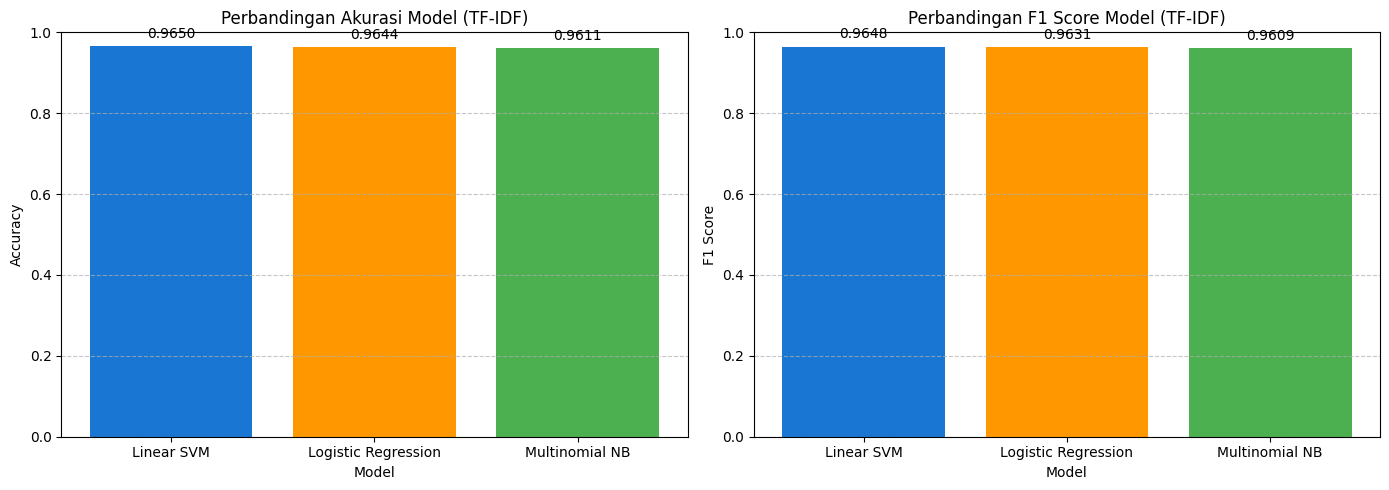


Ringkasan Perbandingan Model
              Model  Accuracy  Precision   Recall  F1 Score
         Linear SVM  0.965030   0.964597 0.965030  0.964796
Logistic Regression  0.964383   0.962793 0.964383  0.963120
     Multinomial NB  0.961145   0.960752 0.961145  0.960937


In [11]:
model_names = ['Linear SVM', 'Logistic Regression', 'Multinomial NB']
accuracies = [acc_svm, acc_lr, acc_nb]
f1_scores = [f1_svm, f1_lr, f1_nb]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart Accuracy
colors = ['#1976d2', '#ff9800', '#4caf50']
bars1 = axes[0].bar(model_names, accuracies, color=colors)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Perbandingan Akurasi Model (TF-IDF)')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.02,
                 f"{acc:.4f}", ha='center', fontsize=10)

# Bar chart F1 Score
bars2 = axes[1].bar(model_names, f1_scores, color=colors)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Perbandingan F1 Score Model (TF-IDF)')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, f1 + 0.02,
                 f"{f1:.4f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Tabel ringkasan
print("\n" + "=" * 80)
print("Ringkasan Perbandingan Model")
print("=" * 80)
summary = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': [prec_svm, prec_lr, prec_nb],
    'Recall': [rec_svm, rec_lr, rec_nb],
    'F1 Score': f1_scores
})
print(summary.to_string(index=False))

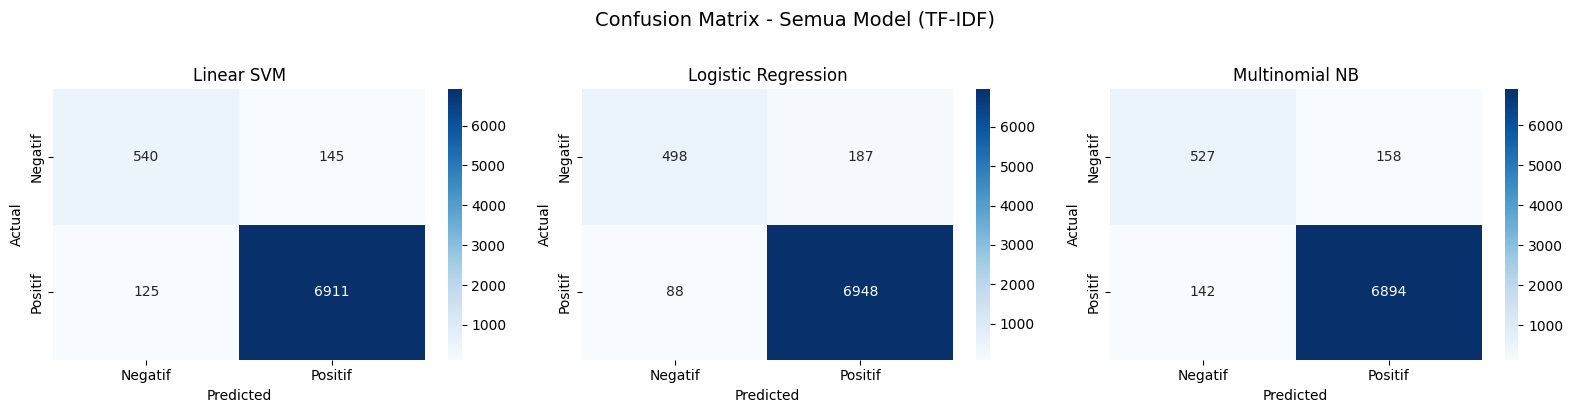

In [12]:
# Confusion Matrix untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cms = [cm_svm, cm_lr, cm_nb]
labels = ['Negatif', 'Positif']

for ax, cm, name in zip(axes, cms, model_names):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix - Semua Model (TF-IDF)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 📝 Kesimpulan

### 🎯 Poin Penting:

1. **Dataset**: 38.603 review apps Indonesia difilter menjadi sentimen biner (positif/negatif, tanpa netral score=3). Rasio positif ~91% menunjukkan dataset **imbalanced**.

2. **TF-IDF Vectorization**: `TfidfVectorizer(max_features=5000)` menghasilkan representasi fitur yang compact dan efisien dari teks review.

3. **Performa Model**: Ketiga model mencapai akurasi >96%, menunjukkan TF-IDF efektif sebagai fitur untuk klasifikasi sentimen.

### 📊 Perbandingan Model:

| Model | Accuracy | F1 Score | Catatan |
|-------|----------|----------|---------|
| Linear SVM | ~96.5% | ~96.5% | Terbaik secara keseluruhan |
| Logistic Regression | ~96.4% | ~96.3% | Precision tertinggi untuk kelas negatif |
| Multinomial NB | ~96.1% | ~96.1% | Paling cepat dalam training |

### 🔧 Langkah Lanjutan:
- Mengatasi class imbalance dengan oversampling/undersampling
- Mencoba fitur tambahan (n-gram, word embeddings)
- Cross-validation untuk evaluasi yang lebih robust

---

## 📚 Referensi

1. [FarhanaTeli/Sentiment_Analysis_IMDB](https://github.com/FarhanaTeli/Sentiment_Analysis_IMDB)
2. scikit-learn Documentation: https://scikit-learn.org/

---

**Terima kasih! Happy Learning! 🎓**